# Poster GPX Playground (Textbox)

Ce notebook te permet de :
- generer une affiche de base a partir d'un GPX
- ajouter une textbox en **cm** (largeur/hauteur)
- ajuster position, police et style
- visualiser le resultat a chaque cellule

In [16]:
# Optionnel: installer les dependances si besoin
# %pip install -r requirements.txt

In [17]:
# Les fonctions utilitaires sont dans poster_toolbox.py.
# Execute la cellule d'import juste en dessous pour charger la version a jour.

In [18]:
from pathlib import Path
import importlib
from PIL import Image
from IPython.display import display

from poster_generator import (
    load_theme,
    read_gpx_points,
    compute_stats,
    build_poster,
 )

import poster_toolbox as pt
importlib.reload(pt)

create_blank_poster = pt.create_blank_poster
set_background = pt.set_background
add_textbox = pt.add_textbox
save_poster = pt.save_poster

In [19]:
# 1) Parametres de base
ROOT = Path('.')
GPX_PATH = ROOT / 'Ski_nordique_dans_l_après_midi.gpx'
THEME_PATH = ROOT / 'theme.example.json'

TITLE = 'Kokopelli Trail'
SUBTITLE = 'Moab, Utah'
DATE_TEXT = '2026-04-18'

WIP_POSTER_PATH = ROOT / 'poster_wip.png'

assert GPX_PATH.exists(), f'GPX introuvable: {GPX_PATH}'
assert THEME_PATH.exists(), f'Theme introuvable: {THEME_PATH}'

In [20]:
# 2) Compute stuff

theme = load_theme(str(THEME_PATH))
points = read_gpx_points(str(GPX_PATH))
stats = compute_stats(points, avg_speed_kmh_fallback=15.0)

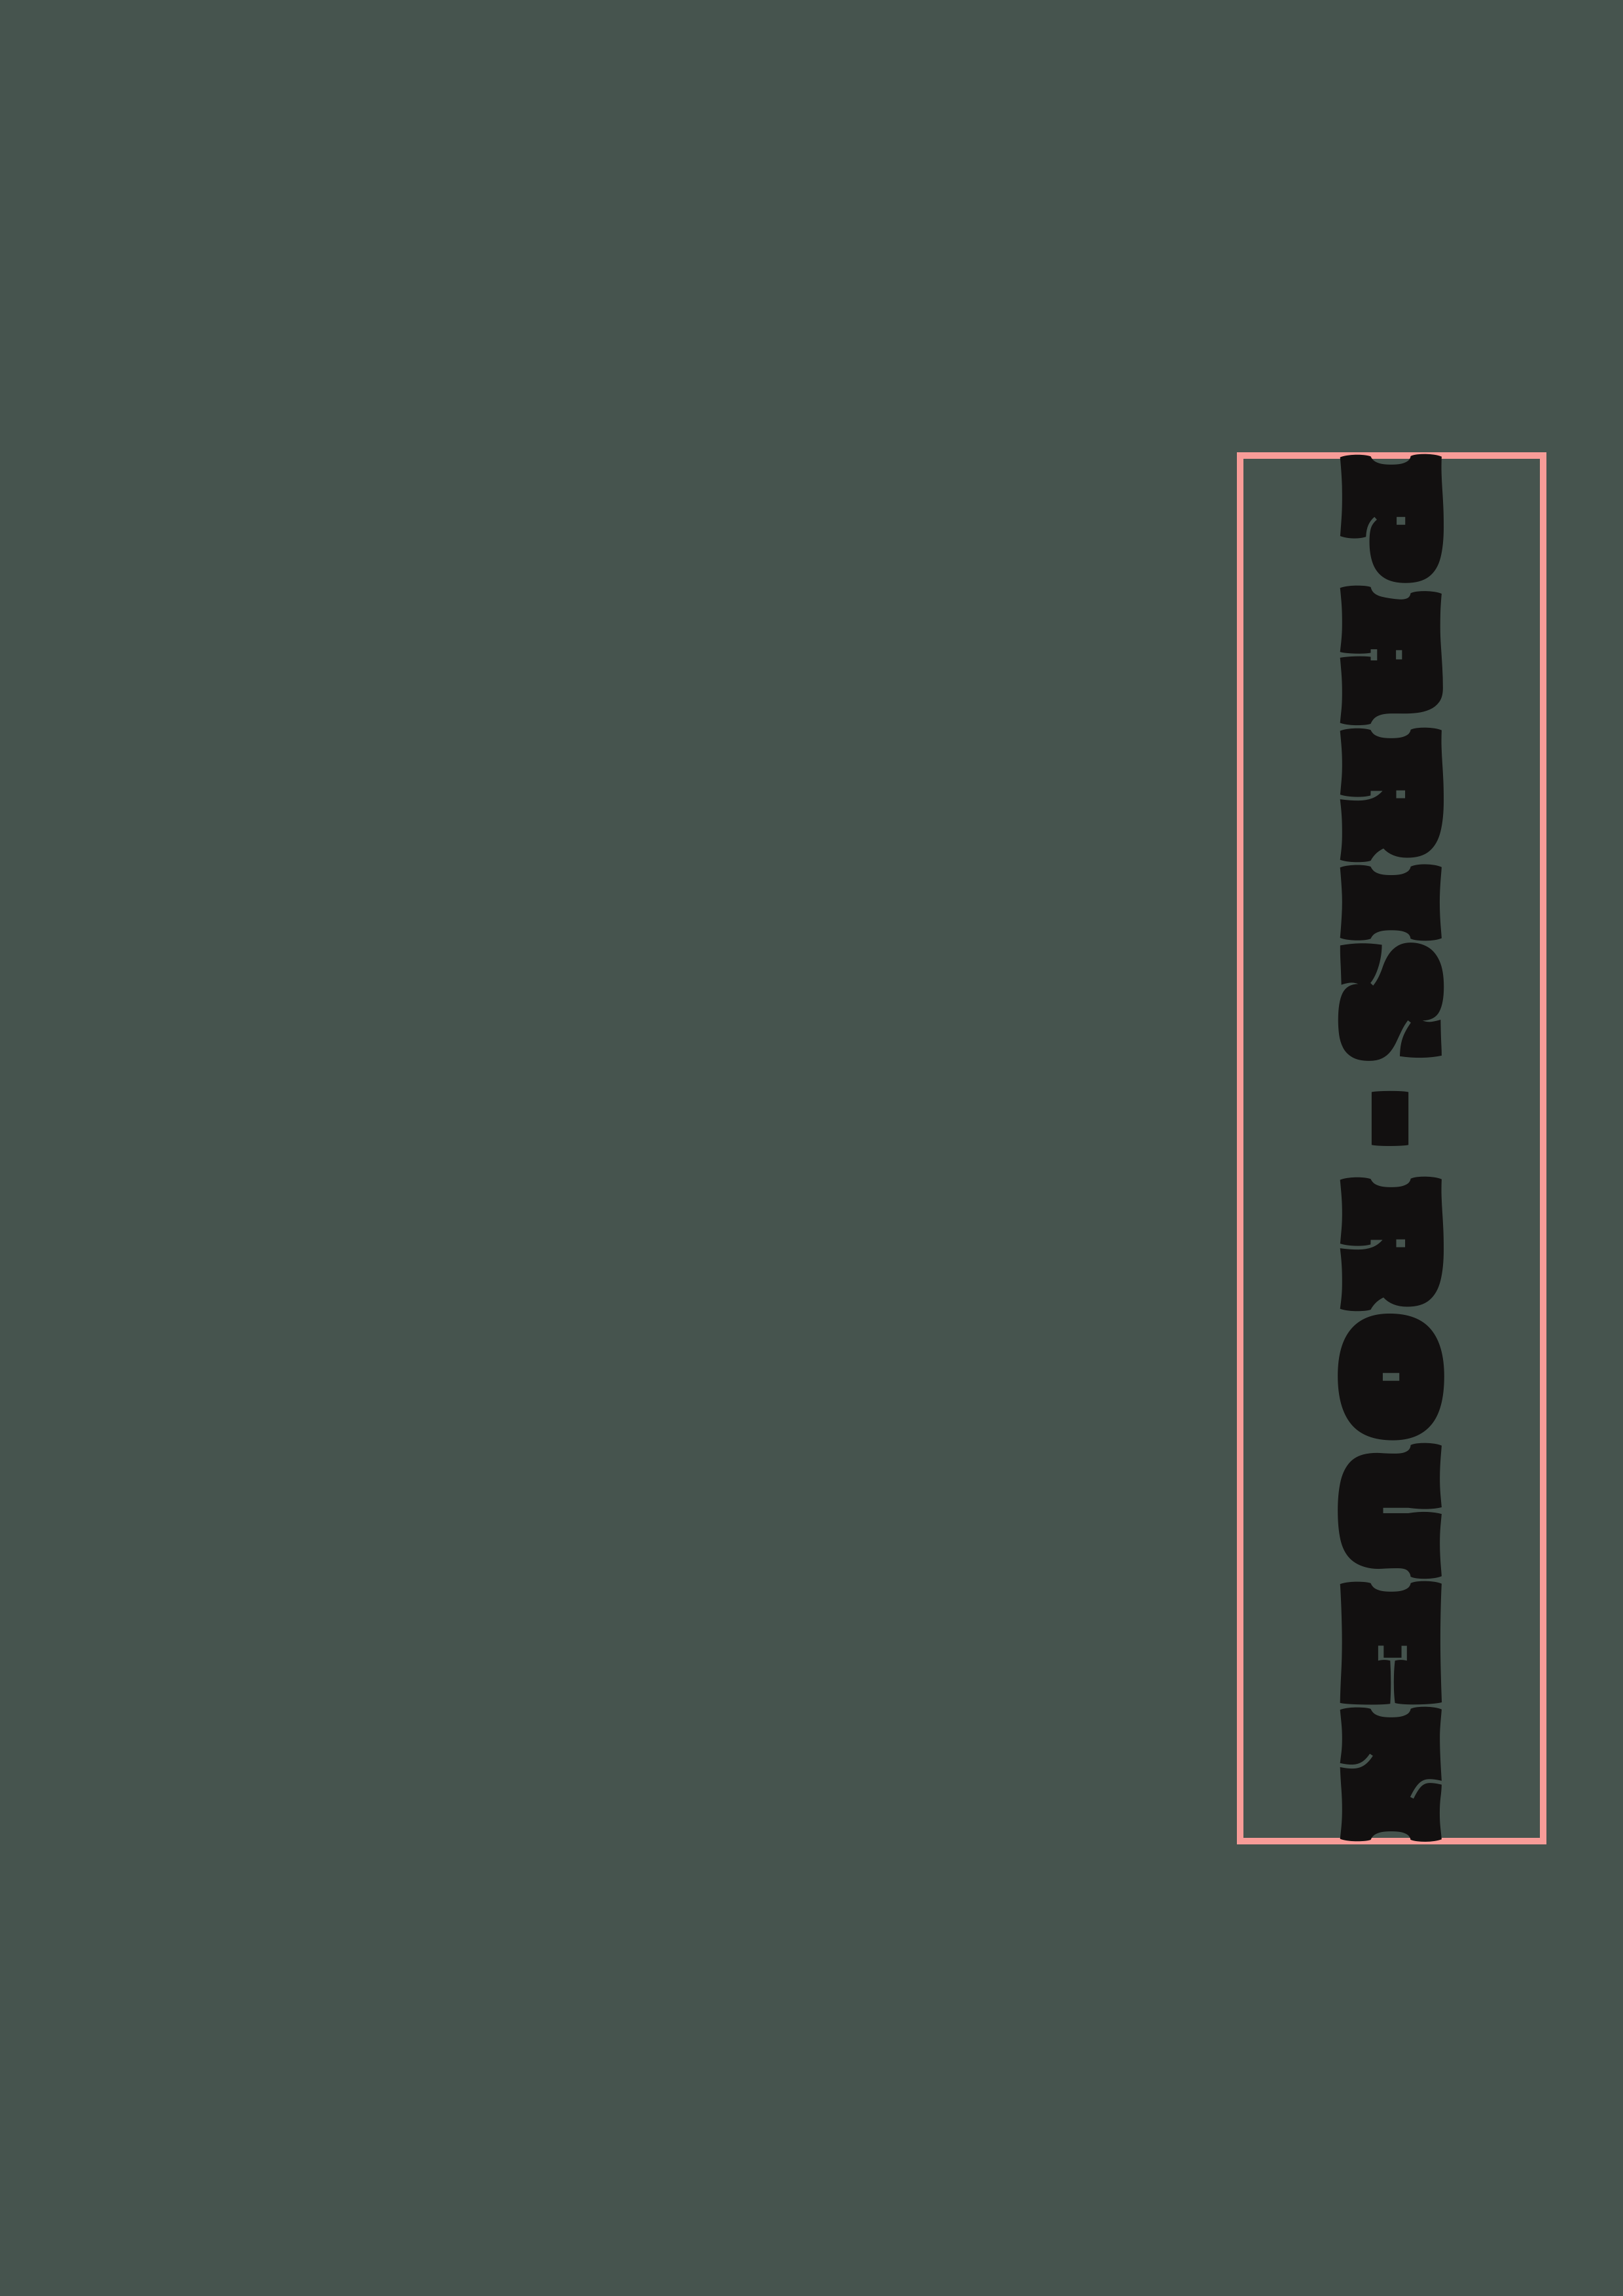

In [ ]:
# 2) Generation de l'affiche de base (sans textbox)

img = create_blank_poster()
img = set_background(img, "#46544E")

img = add_textbox(
    img,
    text="PARIS - ROUEN",
    font_path="fonts/Oi/Oi-Regular.ttf",
    width_cm=4,
    height_cm=18,
    margin_x_cm=1,
    margin_y_cm=2,
    padding_cm=0,
    font_size=None,
    x_cm="right",
    y_cm="center",
    text_align="center",
    text_valign="center",
    text_rotation=0,  # 0, 90, 180, 270
    max_font_size=None,
    wrap_text=False,  # False = une seule ligne, True = multi-lignes
    bg_color="transparent",
    bg_opacity=1.0,
    border_color="#f23b32",
    border_opacity=0.5,
    border_width=10,
    text_color="#121010",
    text_opacity=1.0,
)

display(img)

## Fonction textbox (cm + centrage + police custom)